In [1]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sys.path.append("../src/")  # ensure modules can be imported from src

In [3]:
from data.transform import normalize_time, normalize_formants, seconds_to_milliseconds
from features import euclid, linear

In [4]:
# import data
df = pd.read_csv("../data/raw/001-001.csv")

In [5]:
# add normalized time column
df["time_norm"] = normalize_time(df, "token", "time")

In [6]:
# add normalized formant columns
df["f1p_norm"] = normalize_formants(df, "f1p")
df["f2p_norm"] = normalize_formants(df, "f2p")

In [7]:
# add time column in milliseconds
df["time_ms"] = seconds_to_milliseconds(df, seconds_column="time")

In [8]:
# compute euclidean distances
euclid_df = df.groupby(["token"], as_index=False).apply(
    euclid.compute_distance,
    f1_column="f1p_norm",
    f2_column="f2p_norm",
    include_groups=False,
)

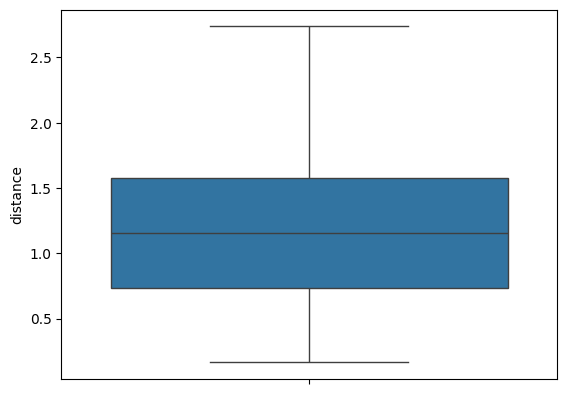

In [9]:
# plot euclidean distances
sns.boxplot(euclid_df["distance"])
plt.show()

In [19]:
# classify vowels based on euclidean distance
euclid_df["classification"] = euclid_df.apply(
    euclid.classify_vowels, axis=1, threshold=1.9
)

In [20]:
# check classifications
euclid_df["classification"].value_counts()

classification
monophthong    34
diphthong       7
Name: count, dtype: int64

In [21]:
# compute LR slopes
linear_df = df.groupby(["token"], as_index=False).apply(
    linear.compute_slopes,
    f1_column="f1p",
    f2_column="f2p",
    include_groups=False,
)

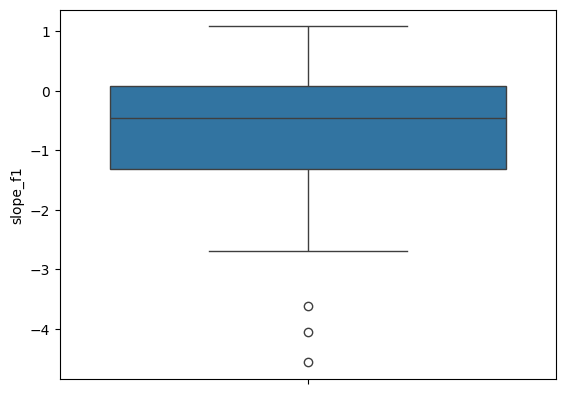

In [22]:
# visualize LR slopes
sns.boxplot(linear_df["slope_f1"])
plt.show()

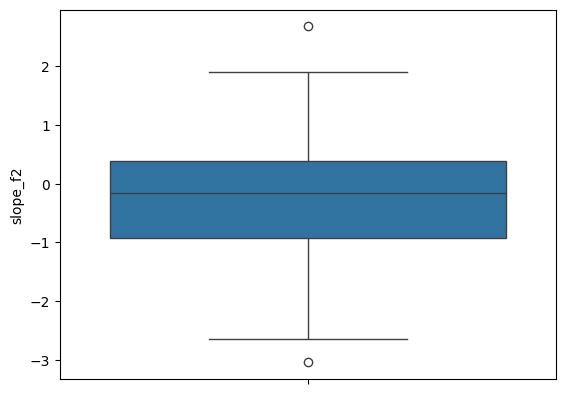

In [23]:
# visualize LR slopes
sns.boxplot(linear_df["slope_f2"])
plt.show()

In [26]:
# classify vowels based on linear slopes
linear_df["classification"] = linear_df.apply(
    linear.classify_tokens, axis=1, threshold_f1=-1, threshold_f2=1
)

In [28]:
# check classifications
linear_df["classification"].value_counts()

classification
monophthong    40
diphthong       1
Name: count, dtype: int64